# Investigate CNS FSRT relation: PTV 1_24Gyin3 -> GTV 1 xxGy

This notebook reproduces the relationship pipeline for the DICOM RT Structure Set `tests/RS.CNS_FSRT_2_GTV.BRAI.dcm` and documents the per-slice relations that are merged into the final relation.

## 1) Load DICOM file and build StructureSet

In [56]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from contour_plotting import plot_ab


In [ ]:
# Ensure src imports work regardless of notebook working directory
cwd = Path.cwd().resolve()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'src').exists() and (candidate / 'tests').exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError('Could not locate repository root containing src/ and tests/.')

src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from dicom import DicomStructureFile
from structure_set import StructureSet
from relations import DE27IM
from region_slice import empty_structure

dicom_path = repo_root / 'tests' / 'RS.CNS_FSRT_2_GTV.BRAI.dcm'
dicom_file = DicomStructureFile(top_dir=repo_root / 'tests',
                                file_path=dicom_path)
structure_set = StructureSet(dicom_structure_file=dicom_file)

print(f'Loaded: {dicom_path}')
print(f'Structures found: {len(structure_set.structures)}')
print(f'Relationship graph edges: {structure_set.relationship_graph.number_of_edges()}')

INFO:dicom:Successfully loaded DICOM dataset from RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Extracted 2911 contours from 35 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.CNS_FSRT_2_GTV.BRAI.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:dicom:Calculated resolution from structure 'BODY': 0.1 cm/pixel
INFO:structure_set:Building StructureSet from 2911 contour points
INFO:structure_set:Calculating relationships for 33 structures
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: divide by zero encountered in relate
  return lib.relate(a, b, **kwargs)
d:\.conda\envs\StructureRelations\Lib\site-packages\shapely\predicates.py:1171: RuntimeWarning: invalid value encountered in relate
  return lib.relate(a, b, **kwargs)
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


Loaded: D:\OneDrive - Queen's University\Python\Projects\StructureRelations\tests\RS.CNS_FSRT_2_GTV.BRAI.dcm
Structures found: 33
Relationship graph edges: 528


## 2) Confirm target structure names and ROI numbers

In [62]:
roi_table = pd.DataFrame([
    {'roi': roi, 'name': structure.name}
    for roi, structure in structure_set.structures.items()
]).sort_values('name').reset_index(drop=True)
#display(roi_table)

def find_roi_by_name(target_name: str, table: pd.DataFrame) -> int:
    exact = table.loc[table['name'] == target_name, 'roi']
    if not exact.empty:
        return int(exact.iloc[0])

    normalized = table['name'].str.lower().str.strip()
    target_norm = target_name.lower().strip()

    exact_norm = table.loc[normalized == target_norm, 'roi']
    if not exact_norm.empty:
        return int(exact_norm.iloc[0])

    contains = table.loc[normalized.str.contains(target_norm, regex=False), 'roi']
    if len(contains) == 1:
        return int(contains.iloc[0])

    raise ValueError(
        f'Could not uniquely resolve ROI for {target_name}. '
        'Check roi_table for actual names.'
    )


In [63]:
def get_slice_relations(structure_a, structure_b):
    slices_a = set(structure_a.region_table['SliceIndex'])
    slices_b = set(structure_b.region_table['SliceIndex'])
    used_slices = slices_a | slices_b

    mask_a = structure_a.region_table.SliceIndex.isin(used_slices) & ~structure_a.region_table.Empty
    mask_b = structure_b.region_table.SliceIndex.isin(used_slices) & ~structure_b.region_table.Empty

    regions_a = structure_a.region_table.loc[mask_a, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions_b = structure_b.region_table.loc[mask_b, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions = regions_a.join(regions_b, how='outer', lsuffix='_a', rsuffix='_b').sort_index()

    cumulative = DE27IM()
    slice_rows = []

    for slice_index, row in regions.iterrows():
        region_a = row['RegionSlice_a']
        region_b = row['RegionSlice_b']

        relation = DE27IM(region_a, region_b, tolerance=structure_set.tolerance)
        relation_type = relation.identify_relation()

        cumulative.merge(relation)
        cumulative_type = cumulative.identify_relation()

        slice_rows.append({
            'slice_index': float(slice_index),
            'a_present': not empty_structure(region_a),
            'b_present': not empty_structure(region_b),
            'slice_relation_type': relation_type.relation_type if relation_type else None,
            'slice_relation_label': relation_type.label if relation_type else None,
            'slice_de27im_bits': relation.relation,
            'slice_de27im_int': relation.int,
            'cumulative_relation_type': cumulative_type.relation_type if cumulative_type else None,
            'cumulative_relation_label': cumulative_type.label if cumulative_type else None,
            'cumulative_de27im_bits': cumulative.relation,
            'cumulative_de27im_int': cumulative.int,
        })

    slice_relation_df = pd.DataFrame(slice_rows).sort_values('slice_index').reset_index(drop=True)
    return slice_relation_df, cumulative

In [64]:
def plot_slice(slice_idx, structure_a, structure_b, slice_relation_df):
    # Get the RegionSlice objects for both structures at this slice
    region_a = structure_a.get_slice(slice_idx)
    region_b = structure_b.get_slice(slice_idx)

    # Create figure and plot
    fig, ax = plt.subplots(figsize=(8, 8))

    try:
        plot_ab(region_a, region_b, axes=ax, add_axis=True)

        # Get the relation type for this slice from our dataframe
        slice_rel = slice_relation_df[slice_relation_df['slice_index'] == slice_idx]
        if not slice_rel.empty:
            rel_label = slice_rel.iloc[0]['slice_relation_label']
            ax.set_title(
                f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}\n'
                f'Slice relation: {rel_label}',
                fontsize=12
            )
        else:
            ax.set_title(f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}', fontsize=12)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(e)}',
            ha='center', va='center')
        ax.set_title(f'z={slice_idx:.2f}')

    plt.tight_layout()
    plt.show()

    print('\n🔍 Plot Legend:')
    print('  Blue area: Only in A (PTV Total)')
    print('  Green area: Only in B (GTV 1 xxGy)')
    print('  Orange area: Intersection (both A and B)')
    print('  Gray dashed lines: Origin (X=0, Y=0)')

## 3) Final relationship reported by StructureSet

In [ ]:
target_a_name = 'PTV Total'
target_b_name = 'GTV 1 xxGy'


In [66]:

roi_a = find_roi_by_name(target_a_name, roi_table)
roi_b = find_roi_by_name(target_b_name, roi_table)

print(f'{target_a_name} -> ROI {roi_a}')
print(f'{target_b_name} -> ROI {roi_b}')
print('\n')
relationship = structure_set.get_relationship(roi_a, roi_b)

print(f'A: {structure_set.structures[roi_a].name} (ROI {roi_a})')
print(f'B: {structure_set.structures[roi_b].name} (ROI {roi_b})')
print('\n')
print(f'Final relation type: {relationship.relationship_type.label}')
print(f'Final relation type key: {relationship.relationship_type.relation_type}')
print(f'Final DE27IM bits: {relationship.de27im.relation}')
print(f'Final DE27IM int: {relationship.de27im.int}')

structure_a = structure_set.structures[roi_a]
structure_b = structure_set.structures[roi_b]

PTV Total -> ROI 15
GTV 1 xxGy -> ROI 4


A: PTV Total (ROI 15)
B: GTV 1 xxGy (ROI 4)


Final relation type: Overlaps
Final relation type key: OVERLAPS
Final DE27IM bits: 111011111111011001111011001
Final DE27IM int: 125809625


In [67]:
slice_relation_df, cumulative = get_slice_relations(structure_a, structure_b)

## 4) Slice-by-slice relations and cumulative merge

This mirrors `StructureShape.relate()`:
- iterate union of non-empty slices for A and B
- compute per-slice `DE27IM(region_a, region_b, tolerance=structure_set.tolerance)`
- merge with bitwise OR into cumulative DE27IM

## 5) Consistency checks

In [68]:
print('StructureSet final relation type:', relationship.relationship_type.relation_type)
print('Reconstructed final relation type:', cumulative.identify_relation().relation_type)
print('StructureSet DE27IM bits       :', relationship.de27im.relation)
print('Reconstructed DE27IM bits      :', cumulative.relation)

assert relationship.de27im.int == cumulative.int, (
    'Mismatch between StructureSet final relation and reconstructed cumulative relation.'
)
print('✅ Reconstructed cumulative relation matches StructureSet output.')

StructureSet final relation type: OVERLAPS
Reconstructed final relation type: OVERLAPS
StructureSet DE27IM bits       : 111011111111011001111011001
Reconstructed DE27IM bits      : 111011111111011001111011001
✅ Reconstructed cumulative relation matches StructureSet output.


## 6) Focused view: slices where both structures are present

In [69]:
both_present = slice_relation_df[slice_relation_df['a_present'] & slice_relation_df['b_present']].copy()
display(both_present)


,slice_index,a_present,b_present,slice_relation_type,slice_relation_label,slice_de27im_bits,slice_de27im_int,cumulative_relation_type,cumulative_relation_label,cumulative_de27im_bits,cumulative_de27im_int
18,-0.35,True,True,NaN,NaN,011011001000000000000000000,56885248,NaN,NaN,011011001001001001001001001,56922697
19,-0.30,True,True,PARTITIONED,Partitioned by,111011001111011001111011001,124236761,PARTITIONED,Partitioned by,111011001111011001111011001,124236761
20,-0.25,True,True,CONTAINS,Contains,111001001111001001111001001,120034249,PARTITIONED,Partitioned by,111011001111011001111011001,124236761
21,-0.20,True,True,CONTAINS,Contains,111001001111001001111001001,120034249,PARTITIONED,Partitioned by,111011001111011001111011001,124236761
22,-0.10,True,True,PARTITIONED,Partitioned by,111011001111011001111011001,124236761,PARTITIONED,Partitioned by,111011001111011001111011001,124236761
23,-0.05,True,True,NaN,NaN,000001111000000000000000000,3932160,OVERLAPS,Overlaps,111011111111011001111011001,125809625
24,0.00,True,True,PARTITIONED,Partitioned by,111011001111011001111011001,124236761,OVERLAPS,Overlaps,111011111111011001111011001,125809625
25,0.10,True,True,PARTITIONED,Partitioned by,111011001111011001111011001,124236761,OVERLAPS,Overlaps,111011111111011001111011001,125809625
26,0.20,True,True,PARTITIONED,Partitioned by,111011001111011001111011001,124236761,OVERLAPS,Overlaps,111011111111011001111011001,125809625
27,0.30,True,True,PARTITIONED,Partitioned by,111011001111011001111011001,124236761,OVERLAPS,Overlaps,111011111111011001111011001,125809625


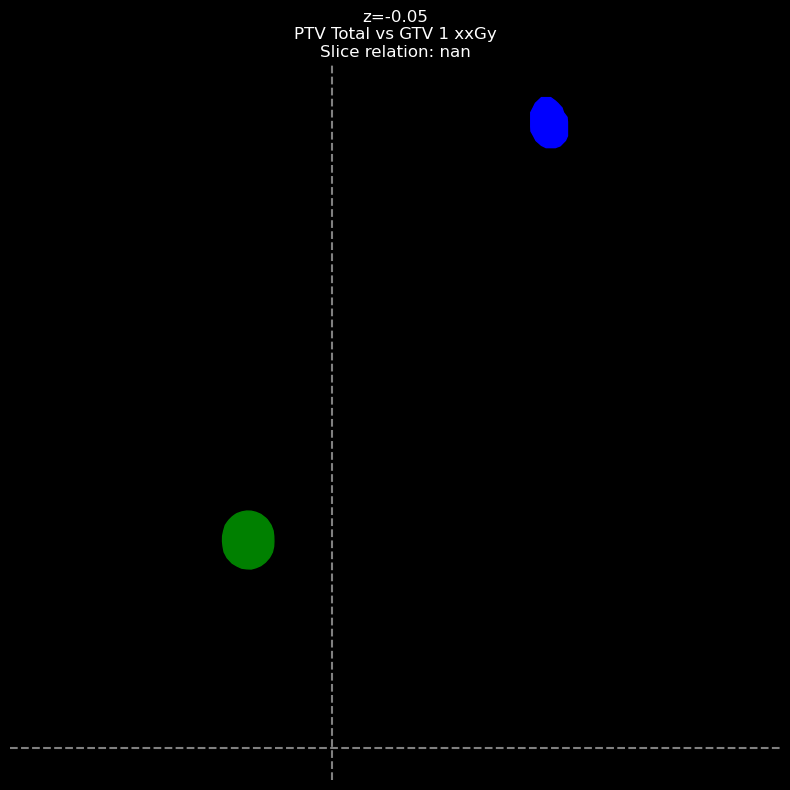


🔍 Plot Legend:
  Blue area: Only in A (PTV Total)
  Green area: Only in B (GTV 1 xxGy)
  Orange area: Intersection (both A and B)
  Gray dashed lines: Origin (X=0, Y=0)


In [75]:
# Plot slice -0.00 directly using plot_ab
slice_idx = -0.05
plot_slice(slice_idx, structure_a, structure_b, slice_relation_df)

In [ ]:

print('Per-slice relation counts (all used slices):')
display(slice_relation_df['slice_relation_label'].value_counts(dropna=False).to_frame('count'))

print('Per-slice relation counts (both-present slices only):')
display(both_present['slice_relation_label'].value_counts(dropna=False).to_frame('count'))

## 7) Relationship validation table: Expected vs Actual

In [35]:
# Define expected relationships based on clinical/geometric requirements
expected_relations = {
    ('PTV Total', 'GTV 1 xxGy'): 'Contains',
    ('PTV Total', 'GTV 2 xxGy'): 'Contains',
    ('PTV Total', 'GTV Total'): 'Contains',
    ('PTV Total', 'PTV 1 24Gyin3'): 'Contains',
    ('PTV Total', 'PTV 2 24Gyin3'): 'Contains',
    ('PTV 1 24Gyin3', 'GTV 2 xxGy'): 'Disjoint',
    ('PTV 1 24Gyin3', 'GTV Total'): 'Overlaps',
    ('PTV 1 24Gyin3', 'PTV 2 24Gyin3'): 'Disjoint',
    ('PTV 2 24Gyin3', 'PTV 1 xxGy'): 'Contains',
    ('PTV 2 24Gyin3', 'GTV 1 xxGy'): 'Disjoint',
    ('PTV 2 24Gyin3', 'GTV 2 xxGy'): 'Contains',
    ('PTV 2 24Gyin3', 'GTV Total'): 'Overlaps',
    ('GTV Total', 'GTV 1 xxGy'): 'Contains',
    ('GTV Total', 'GTV 2 xxGy'): 'Contains',
    ('GTV 1 xxGy', 'GTV 2 xxGy'): 'Disjoint',
}

# Build ROI name lookup
roi_to_name = {roi: structure.name for roi, structure in structure_set.structures.items()}
name_to_roi = {structure.name: roi for roi, structure in structure_set.structures.items()}

# Collect results
comparison_rows = []
for (name_a, name_b), expected_type in expected_relations.items():
    if name_a not in name_to_roi or name_b not in name_to_roi:
        print(f'Warning: Could not find ROI for {name_a} or {name_b}')
        continue

    roi_a = name_to_roi[name_a]
    roi_b = name_to_roi[name_b]

    rel = structure_set.get_relationship(roi_a, roi_b)
    actual_type = rel.relationship_type.label if rel and rel.relationship_type else 'Unknown'

    is_match = (expected_type == actual_type)

    comparison_rows.append({
        'Structure A': name_a,
        'Structure B': name_b,
        'Expected': expected_type,
        'Actual': actual_type,
        'Match': '✅' if is_match else '❌',
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

# Show mismatches
mismatches = comparison_df[comparison_df['Match'] == '❌']
print(f'\n⚠️ INCORRECT RELATIONSHIPS: {len(mismatches)} out of {len(comparison_df)}')
if len(mismatches) > 0:
    display(mismatches[['Structure A', 'Structure B', 'Expected', 'Actual']])

,Structure A,Structure B,Expected,Actual,Match
0,PTV Total,GTV 1 xxGy,Contains,Overlaps,❌
1,PTV Total,GTV 2 xxGy,Contains,Overlaps,❌
2,PTV Total,GTV Total,Contains,Overlaps,❌
3,GTV Total,GTV 1 xxGy,Contains,Overlaps,❌
4,GTV Total,GTV 2 xxGy,Contains,Overlaps,❌
5,GTV 1 xxGy,GTV 2 xxGy,Disjoint,Disjoint,✅



⚠️ INCORRECT RELATIONSHIPS: 5 out of 6


,Structure A,Structure B,Expected,Actual
0,PTV Total,GTV 1 xxGy,Contains,Overlaps
1,PTV Total,GTV 2 xxGy,Contains,Overlaps
2,PTV Total,GTV Total,Contains,Overlaps
3,GTV Total,GTV 1 xxGy,Contains,Overlaps
4,GTV Total,GTV 2 xxGy,Contains,Overlaps


## 8) Visualize contours with plot_ab

In [36]:
# Check which slices actually have both structures
print('Slices with structure A (PTV Total):')
slices_with_a = sorted(slice_relation_df[slice_relation_df['a_present']]['slice_index'].unique())
print(slices_with_a)

print('\nSlices with structure B (GTV 1 xxGy):')
slices_with_b = sorted(slice_relation_df[slice_relation_df['b_present']]['slice_index'].unique())
print(slices_with_b)

print('\nSlices with BOTH A and B:')
slices_with_both = sorted(slice_relation_df[slice_relation_df['a_present'] & slice_relation_df['b_present']]['slice_index'].unique())
print(slices_with_both)

if 0.0 not in slices_with_both:
    print(f'\n⚠️ Slice 0.0 does not have both structures!')
    if len(slices_with_both) > 0:
        print(f'Using first slice with both structures: {slices_with_both[0]}')

Slices with structure A (PTV Total):
[np.float64(-1.35), np.float64(-1.3), np.float64(-1.2), np.float64(-1.15), np.float64(-1.1), np.float64(-1.05), np.float64(-1.0), np.float64(-0.95), np.float64(-0.9), np.float64(-0.8), np.float64(-0.75), np.float64(-0.7), np.float64(-0.65), np.float64(-0.6), np.float64(-0.55), np.float64(-0.5), np.float64(-0.45), np.float64(-0.4), np.float64(-0.35), np.float64(-0.3), np.float64(-0.25), np.float64(-0.2), np.float64(-0.1), np.float64(-0.05), np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.8), np.float64(0.85)]

Slices with structure B (GTV 1 xxGy):
[np.float64(-0.35), np.float64(-0.3), np.float64(-0.25), np.float64(-0.2), np.float64(-0.1), np.float64(-0.05), np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.6), np.float64(0.65)]

Slice

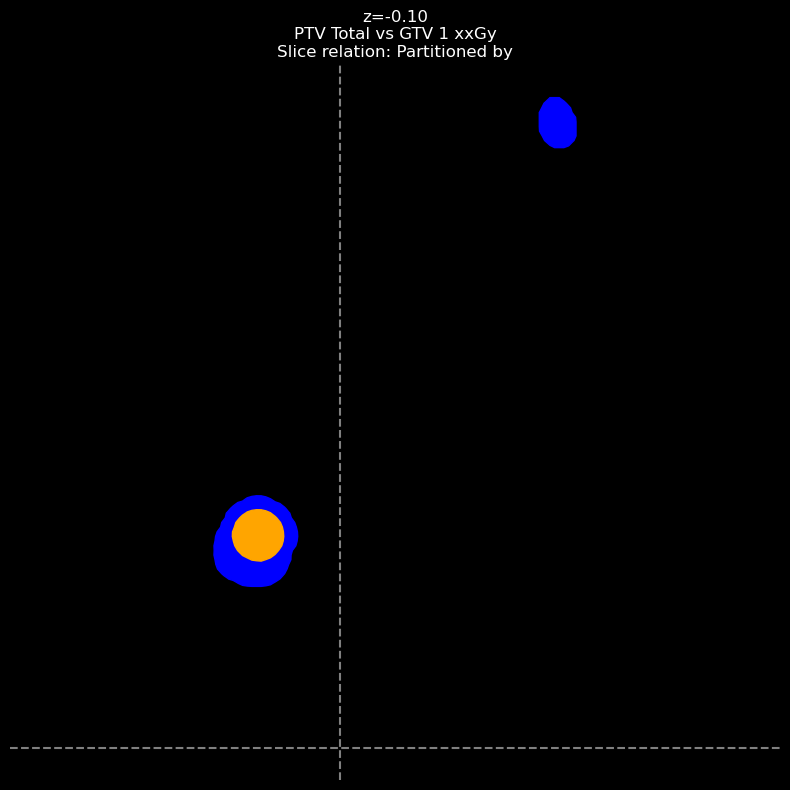


🔍 Plot Legend:
  Blue area: Only in A (PTV Total)
  Green area: Only in B (GTV 1 xxGy)
  Orange area: Intersection (both A and B)
  Gray dashed lines: Origin (X=0, Y=0)


In [39]:
import matplotlib.pyplot as plt
from contour_plotting import plot_ab

# Plot slice -0.00 directly using plot_ab
slice_idx = -0.10

# Get the RegionSlice objects for both structures at this slice
region_a = structure_a.get_slice(slice_idx)
region_b = structure_b.get_slice(slice_idx)

# Create figure and plot
fig, ax = plt.subplots(figsize=(8, 8))

try:
    plot_ab(region_a, region_b, axes=ax, add_axis=True)

    # Get the relation type for this slice from our dataframe
    slice_rel = slice_relation_df[slice_relation_df['slice_index'] == slice_idx]
    if not slice_rel.empty:
        rel_label = slice_rel.iloc[0]['slice_relation_label']
        ax.set_title(
            f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}\n'
            f'Slice relation: {rel_label}',
            fontsize=12
        )
    else:
        ax.set_title(f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}', fontsize=12)
except Exception as e:
    ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(e)}',
           ha='center', va='center')
    ax.set_title(f'z={slice_idx:.2f}')

plt.tight_layout()
plt.show()

print('\n🔍 Plot Legend:')
print('  Blue area: Only in A (PTV Total)')
print('  Green area: Only in B (GTV 1 xxGy)')
print('  Orange area: Intersection (both A and B)')
print('  Gray dashed lines: Origin (X=0, Y=0)')

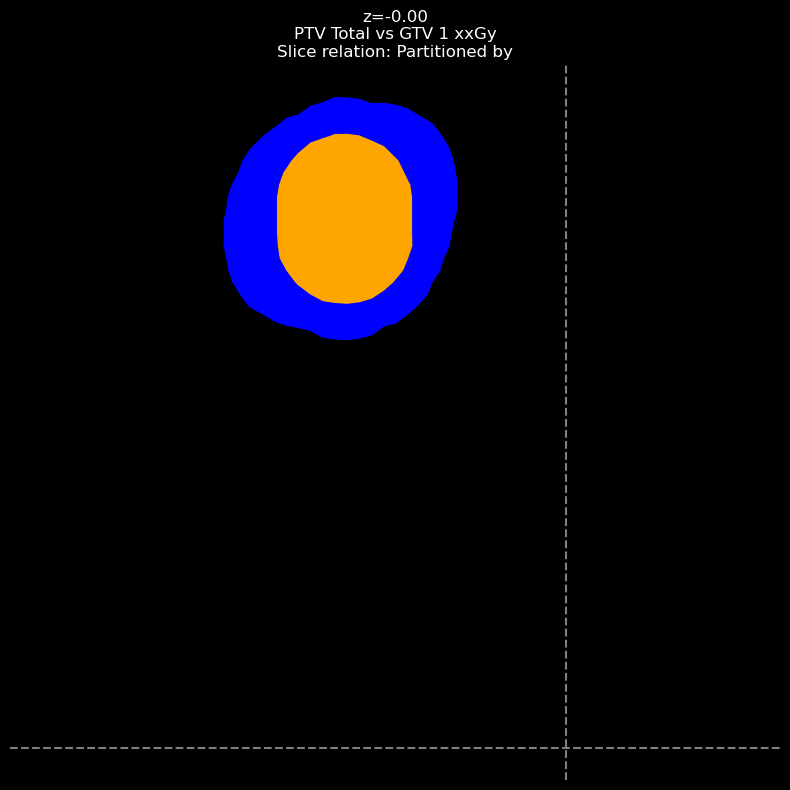


🔍 Plot Legend:
  Blue area: Only in A (PTV Total)
  Green area: Only in B (GTV 1 xxGy)
  Orange area: Intersection (both A and B)
  Gray dashed lines: Origin (X=0, Y=0)


In [ ]:
import matplotlib.pyplot as plt
from contour_plotting import plot_ab

# Plot slice -0.00 directly using plot_ab
slice_idx = -0.00

# Get the RegionSlice objects for both structures at this slice
region_a = structure_a.get_slice(slice_idx)
region_b = structure_b.get_slice(slice_idx)

# Create figure and plot
fig, ax = plt.subplots(figsize=(8, 8))

try:
    plot_ab(region_a, region_b, axes=ax, add_axis=True)

    # Get the relation type for this slice from our dataframe
    slice_rel = slice_relation_df[slice_relation_df['slice_index'] == slice_idx]
    if not slice_rel.empty:
        rel_label = slice_rel.iloc[0]['slice_relation_label']
        ax.set_title(
            f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}\n'
            f'Slice relation: {rel_label}',
            fontsize=12
        )
    else:
        ax.set_title(f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}', fontsize=12)
except Exception as e:
    ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(e)}',
           ha='center', va='center')
    ax.set_title(f'z={slice_idx:.2f}')

plt.tight_layout()
plt.show()

print('\n🔍 Plot Legend:')
print('  Blue area: Only in A (PTV Total)')
print('  Green area: Only in B (GTV 1 xxGy)')
print('  Orange area: Intersection (both A and B)')
print('  Gray dashed lines: Origin (X=0, Y=0)')

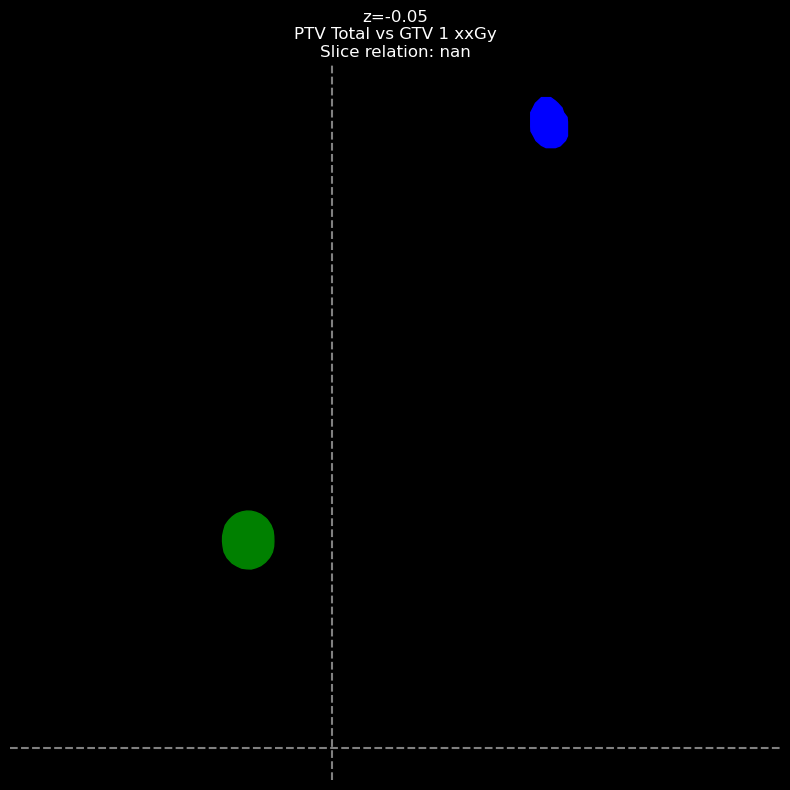


🔍 Plot Legend:
  Blue area: Only in A (PTV Total)
  Green area: Only in B (GTV 1 xxGy)
  Orange area: Intersection (both A and B)
  Gray dashed lines: Origin (X=0, Y=0)


In [ ]:
import matplotlib.pyplot as plt
from contour_plotting import plot_ab

# Plot slice -0.05 directly using plot_ab
slice_idx = -0.05

# Get the RegionSlice objects for both structures at this slice
region_a = structure_a.get_slice(slice_idx)
region_b = structure_b.get_slice(slice_idx)

# Create figure and plot
fig, ax = plt.subplots(figsize=(8, 8))

try:
    plot_ab(region_a, region_b, axes=ax, add_axis=True)

    # Get the relation type for this slice from our dataframe
    slice_rel = slice_relation_df[slice_relation_df['slice_index'] == slice_idx]
    if not slice_rel.empty:
        rel_label = slice_rel.iloc[0]['slice_relation_label']
        ax.set_title(
            f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}\n'
            f'Slice relation: {rel_label}',
            fontsize=12
        )
    else:
        ax.set_title(f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}', fontsize=12)
except Exception as e:
    ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(e)}',
           ha='center', va='center')
    ax.set_title(f'z={slice_idx:.2f}')

plt.tight_layout()
plt.show()

print('\n🔍 Plot Legend:')
print('  Blue area: Only in A (PTV Total)')
print('  Green area: Only in B (GTV 1 xxGy)')
print('  Orange area: Intersection (both A and B)')
print('  Gray dashed lines: Origin (X=0, Y=0)')

## 9) Diagnose relationship classification mismatch

In [14]:
from relations import DE27IM, RELATIONSHIP_TYPES

# Get the relation for slice 0.0
slice_idx = 0.0
slice_relation = DE27IM(region_a, region_b)
slice_relation_int = slice_relation.int
slice_relation_bits = slice_relation.relation

print(f'Slice {slice_idx} DE27IM Analysis:')
print(f'=' * 60)
print(f'DE27IM bits: {slice_relation_bits}')
print(f'DE27IM int:  {slice_relation_int}')
print(f'Identified relation: {slice_relation.identify_relation().label}')
print()

# Show CONTAINS vs PARTITIONS definitions
print('Relationship Pattern Definitions:')
print('-' * 60)
contains_type = RELATIONSHIP_TYPES.get('CONTAINS')
partitions_type = RELATIONSHIP_TYPES.get('PARTITIONS')

print(f'CONTAINS:')
if contains_type:
    print(f'  Pattern: {contains_type.pattern}')
    print(f'  Mask:    {contains_type.mask}')
    print(f'  Value:   {contains_type.value}')
    print(f'  Mask (decimal):  {contains_type.mask_decimal}')
    print(f'  Value (decimal): {contains_type.value_decimal}')
print()

print(f'PARTITIONS:')
if partitions_type:
    print(f'  Pattern: {partitions_type.pattern}')
    print(f'  Mask:    {partitions_type.mask}')
    print(f'  Value:   {partitions_type.value}')
    print(f'  Mask (decimal):  {partitions_type.mask_decimal}')
    print(f'  Value (decimal): {partitions_type.value_decimal}')
print()

# Test which patterns match
print('Pattern Matching:')
print('-' * 60)
print(f'Against CONTAINS:')
if contains_type:
    mask = contains_type.mask_decimal
    value = contains_type.value_decimal
    result = slice_relation_int & mask
    matches = result == value
    print(f'  (slice_int & mask) = ({slice_relation_int} & {mask}) = {result}')
    print(f'  Matches value {value}? {matches}')
print()

print(f'Against PARTITIONS:')
if partitions_type:
    mask = partitions_type.mask_decimal
    value = partitions_type.value_decimal
    result = slice_relation_int & mask
    matches = result == value
    print(f'  (slice_int & mask) = ({slice_relation_int} & {mask}) = {result}')
    print(f'  Matches value {value}? {matches}')
print()

# Show the cumulative relation
print('Cumulative (across all slices):')
print('-' * 60)
print(f'Cumulative DE27IM bits: {relationship.de27im.relation}')
print(f'Cumulative DE27IM int:  {relationship.de27im.int}')
print(f'Final identified relation: {relationship.relationship_type.label}')

Slice 0.0 DE27IM Analysis:
DE27IM bits: 111001001111001001111001001
DE27IM int:  120034249
Identified relation: Contains

Relationship Pattern Definitions:
------------------------------------------------------------
CONTAINS:
  Pattern: TT*FF*F**	T********	T********
  Mask:    0b110110100100000000100000000
  Value:   0b110000000100000000100000000
  Mask (decimal):  114426112
  Value (decimal): 100794624

PARTITIONS:
  Pattern: 
  Mask:    
  Value:   
  Mask (decimal):  0
  Value (decimal): 0

Pattern Matching:
------------------------------------------------------------
Against CONTAINS:
  (slice_int & mask) = (120034249 & 114426112) = 100794624
  Matches value 100794624? True

Against PARTITIONS:
  (slice_int & mask) = (120034249 & 0) = 0
  Matches value 0? True

Cumulative (across all slices):
------------------------------------------------------------
Cumulative DE27IM bits: 111011001111011001111011001
Cumulative DE27IM int:  124236761
Final identified relation: Partitioned by


In [ ]:
print('\n' + '=' * 70)
print('CHECKING ALL RELATIONSHIP DEFINITIONS FOR PATTERN ISSUES')
print('=' * 70)

# Check all relationship types for missing patterns
missing_patterns = []
for rel_name, rel_type in sorted(RELATIONSHIP_TYPES.items()):
    has_pattern = bool(rel_type.pattern)
    has_mask = rel_type.mask_decimal is not None and rel_type.mask_decimal != 0
    has_value = rel_type.value_decimal is not None

    status = '✅ HAS PATTERN' if has_pattern else '❌ NO PATTERN'
    print(f'{rel_name:20s} | {status:20s} | Mask: {rel_type.mask_decimal:12} | Value: {rel_type.value_decimal:12}')

    if not has_pattern and rel_name not in ['UNKNOWN', 'EQUALS']:
        missing_patterns.append(rel_name)

if missing_patterns:
    print(f'\n⚠️  CRITICAL ISSUE: {len(missing_patterns)} relationship(s) missing pattern definitions:')
    for rel_name in missing_patterns:
        print(f'   - {rel_name}')
    print(f'\nThese relationships CANNOT be identified by pattern matching!')
    print(f'They will either never match or cause incorrect classifications.')

# Show PARTITIONS specifically
print(f'\n' + '=' * 70)
print('DETAILED LOOK: PARTITIONS vs PARTITIONED')
print('=' * 70)
part_type = RELATIONSHIP_TYPES.get('PARTITIONS')
partd_type = RELATIONSHIP_TYPES.get('PARTITIONED')

print(f'PARTITIONS:')
print(f'  Label: {part_type.label}')
print(f'  Pattern: {repr(part_type.pattern)}')
print(f'  Reversed arrow: {part_type.reversed_arrow}')
print(f'  Defined: {bool(part_type.pattern)}')

print(f'\nPARTITIONED:')
print(f'  Label: {partd_type.label}')
print(f'  Pattern: {repr(partd_type.pattern)}')
print(f'  Reversed arrow: {partd_type.reversed_arrow}')
print(f'  Defined: {bool(partd_type.pattern)}')


CHECKING ALL RELATIONSHIP DEFINITIONS FOR PATTERN ISSUES
BORDERS              | ✅ HAS PATTERN        | Mask:     71305216 | Value:      4196352
CONFINED             | ❌ NO PATTERN         | Mask:            0 | Value:            0
CONFINES             | ✅ HAS PATTERN        | Mask:     71469056 | Value:      4358144
CONTAINS             | ✅ HAS PATTERN        | Mask:    114426112 | Value:    100794624
DISJOINT             | ✅ HAS PATTERN        | Mask:    113256468 | Value:         2052
ENCLOSED             | ❌ NO PATTERN         | Mask:            0 | Value:            0
EQUALS               | ✅ HAS PATTERN        | Mask:     89268480 | Value:     71442688
OVERLAPS             | ✅ HAS PATTERN        | Mask:     68288768 | Value:     68288768
PARTITIONED          | ✅ HAS PATTERN        | Mask:     89128960 | Value:     88080384
PARTITIONS           | ❌ NO PATTERN         | Mask:            0 | Value:            0
SHELTERED            | ❌ NO PATTERN         | Mask:            0 | Value

# Investigation: PTV Total -> GTV 1 xxGy

Expected relationship: **Contains**  
Actual relationship: **Overlaps**

## Resolve ROI numbers for PTV Total and GTV 1 xxGy

In [20]:
# Resolve ROI numbers
target_a_name_2 = 'PTV Total'
target_b_name_2 = 'GTV 1 xxGy'

# Build name mapping from the structure set
name_to_roi_2 = {structure.name: roi for roi, structure in structure_set.structures.items()}

# Try to resolve ROI numbers (exact match first)
roi_a_2 = name_to_roi_2.get(target_a_name_2)
roi_b_2 = name_to_roi_2.get(target_b_name_2)

# Fallback: normalize names and try again
if roi_a_2 is None or roi_b_2 is None:
    normalized_mapping = {name.strip().lower(): (name, roi) for name, roi in name_to_roi_2.items()}

    if roi_a_2 is None:
        match = normalized_mapping.get(target_a_name_2.strip().lower())
        roi_a_2 = match[1] if match else None
        if match:
            target_a_name_2 = match[0]

    if roi_b_2 is None:
        match = normalized_mapping.get(target_b_name_2.strip().lower())
        roi_b_2 = match[1] if match else None
        if match:
            target_b_name_2 = match[0]

if roi_a_2 is None or roi_b_2 is None:
    raise ValueError(f'Could not resolve ROI numbers for {target_a_name_2!r} or {target_b_name_2!r}')

print(f'A: {target_a_name_2!r} -> ROI {roi_a_2}')
print(f'B: {target_b_name_2!r} -> ROI {roi_b_2}')

# Get the structures
structure_a_2 = structure_set.structures[roi_a_2]
structure_b_2 = structure_set.structures[roi_b_2]

print(f'\nStructure A slices: {len(structure_a_2.region_table)}')
print(f'Structure B slices: {len(structure_b_2.region_table)}')

A: 'PTV Total' -> ROI 15
B: 'GTV 1 xxGy' -> ROI 4

Structure A slices: 36
Structure B slices: 15


## Compute slice-by-slice DE27IM relationships

In [21]:
# Get all slice indices
slices_a_2 = set(structure_a_2.region_table['SliceIndex'])
slices_b_2 = set(structure_b_2.region_table['SliceIndex'])
slices_with_both_2 = sorted(slices_a_2 & slices_b_2)

print(f'Slices with structure A only: {len(slices_a_2 - slices_b_2)}')
print(f'Slices with structure B only: {len(slices_b_2 - slices_a_2)}')
print(f'Slices with both: {len(slices_with_both_2)}')
print(f'Both present on slices: {slices_with_both_2}')

# Build DataFrame with regions on each slice
regions_a_2 = pd.DataFrame([
    {'slice_index': si, 'region_a': structure_a_2.get_slice(si)}
    for si in structure_a_2.region_table['SliceIndex']
]).set_index('slice_index')

regions_b_2 = pd.DataFrame([
    {'slice_index': si, 'region_b': structure_b_2.get_slice(si)}
    for si in structure_b_2.region_table['SliceIndex']
]).set_index('slice_index')

regions_2 = regions_a_2.join(regions_b_2, how='outer')

print(f'\nTotal slices to process: {len(regions_2)}')

Slices with structure A only: 21
Slices with structure B only: 0
Slices with both: 15
Both present on slices: [-0.35, -0.3, -0.25, -0.2, -0.1, -0.05, 0.0, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.6, 0.65]

Total slices to process: 36


In [25]:
# Compute DE27IM for each slice
slice_rows_2 = []
cumulative_2 = None

for slice_index, row in regions_2.iterrows():
    region_a_2 = row['region_a']
    region_b_2 = row['region_b']

    slice_relation_2 = DE27IM(region_a_2, region_b_2, tolerance=structure_set.tolerance)

    if cumulative_2 is None:
        cumulative_2 = slice_relation_2
    else:
        cumulative_2.merge(slice_relation_2)

    slice_relation_type_2 = slice_relation_2.identify_relation()
    cumulative_type_2 = cumulative_2.identify_relation()

    slice_rows_2.append({
        'slice_index': slice_index,
        'slice_relation': slice_relation_type_2.relation_type if slice_relation_type_2 else 'UNKNOWN',
        'cumulative': cumulative_type_2.relation_type if cumulative_type_2 else 'UNKNOWN',
        'slice_bits': slice_relation_2.relation,
        'cumulative_bits': cumulative_2.relation
    })

slice_relation_df_2 = pd.DataFrame(slice_rows_2)
display(slice_relation_df_2)

,slice_index,slice_relation,cumulative,slice_bits,cumulative_bits
0,-1.35,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
1,-1.30,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
2,-1.20,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
3,-1.15,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
4,-1.10,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
5,-1.05,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
6,-1.00,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
7,-0.95,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
8,-0.90,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001
9,-0.80,UNKNOWN,UNKNOWN,001001001001001001001001001,001001001001001001001001001


## Visualize contours on representative slices

TypeError: plot_ab() got an unexpected keyword argument 'ax'

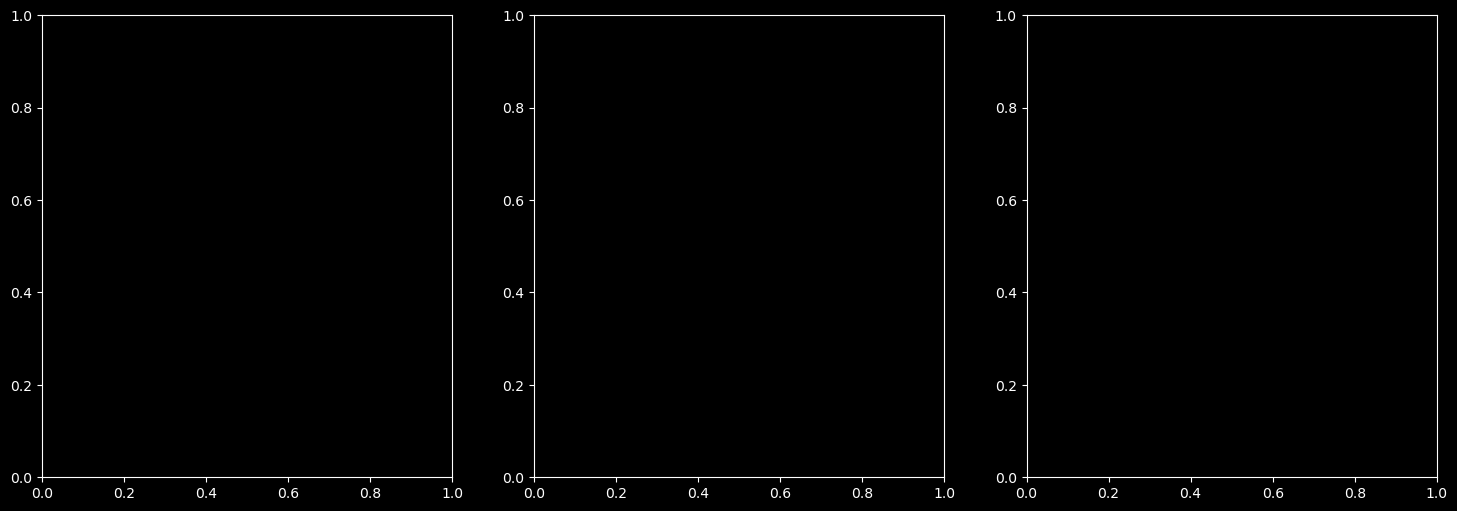

In [26]:
from contour_plotting import plot_ab
import matplotlib.pyplot as plt

# Find slices where both structures are present
both_present_2 = slice_relation_df_2[slice_relation_df_2['slice_relation'] != 'DISJOINT']

if len(both_present_2) > 0:
    # Select representative slices to plot (first, middle, last)
    slice_indices_to_plot_2 = []
    if len(both_present_2) >= 1:
        slice_indices_to_plot_2.append(both_present_2.iloc[0]['slice_index'])
    if len(both_present_2) >= 2:
        slice_indices_to_plot_2.append(both_present_2.iloc[len(both_present_2)//2]['slice_index'])
    if len(both_present_2) >= 3:
        slice_indices_to_plot_2.append(both_present_2.iloc[-1]['slice_index'])

    num_plots_2 = len(slice_indices_to_plot_2)
    fig_2, axes_2 = plt.subplots(1, num_plots_2, figsize=(6*num_plots_2, 6))
    if num_plots_2 == 1:
        axes_2 = [axes_2]

    for idx, slice_idx in enumerate(slice_indices_to_plot_2):
        region_a_2 = regions_2.loc[slice_idx, 'region_a']
        region_b_2 = regions_2.loc[slice_idx, 'region_b']
        slice_rel_2 = slice_relation_df_2[slice_relation_df_2['slice_index'] == slice_idx].iloc[0]

        ax_2 = axes_2[idx]
        plot_ab(region_a_2, region_b_2, ax=ax_2)
        ax_2.set_title(f'Slice {slice_idx:.2f}\\nRelation: {slice_rel_2["slice_relation"]}')
        ax_2.set_xlabel('X (cm)')
        ax_2.set_ylabel('Y (cm)')
        ax_2.legend()
        ax_2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Plotted {num_plots_2} representative slices')
else:
    print('No slices with both structures present')

## Analyze why the relationship is OVERLAPS instead of CONTAINS

In [27]:
# Check the final cumulative relationship
print('Final cumulative relationship:')
print(f'  Type: {cumulative_type_2.relation_type if cumulative_type_2 else "UNKNOWN"}')
print(f'  Binary: {cumulative_2.relation}')
print(f'  Decimal: {cumulative_2.int}')

# Compare against the structure set's computed relationship
relationship_2 = structure_set.relationship_graph[roi_a_2][roi_b_2]['relationship']
print(f'\nStructureSet relationship: {relationship_2.relation_type.relation_type}')
print(f'  Binary: {relationship_2.de27im.relation}')
print(f'  Decimal: {relationship_2.de27im.int}')

# Check if they match
if cumulative_2.int == relationship_2.de27im.int:
    print('\n✅ Cumulative DE27IM matches StructureSet DE27IM')
else:
    print('\n❌ Cumulative DE27IM does NOT match StructureSet DE27IM')
    print('This indicates a potential issue in how the structures are merged')

# Analyze CONTAINS vs OVERLAPS pattern
from relations import RelationshipType
from relationship_definitions import RELATIONSHIP_TYPES

contains_def = RELATIONSHIP_TYPES[RelationshipType.CONTAINS]
overlaps_def = RELATIONSHIP_TYPES[RelationshipType.OVERLAPS]

print(f'\n--- CONTAINS Pattern ---')
print(f'Pattern: {contains_def.pattern}')
print(f'Mask:    {contains_def.mask_decimal}')
print(f'Value:   {contains_def.value_decimal}')

print(f'\n--- OVERLAPS Pattern ---')
print(f'Pattern: {overlaps_def.pattern}')
print(f'Mask:    {overlaps_def.mask_decimal}')
print(f'Value:   {overlaps_def.value_decimal}')

# Test cumulative against CONTAINS pattern
cumulative_int_2 = cumulative_2.int
contains_mask = contains_def.mask_decimal
contains_value = contains_def.value_decimal
overlaps_mask = overlaps_def.mask_decimal
overlaps_value = overlaps_def.value_decimal

contains_matches = (cumulative_int_2 & contains_mask) == contains_value
overlaps_matches = (cumulative_int_2 & overlaps_mask) == overlaps_value

print(f'\n--- Pattern Matching Results ---')
print(f'CONTAINS matches: {contains_matches}')
print(f'OVERLAPS matches: {overlaps_matches}')

if not contains_matches and overlaps_matches:
    print('\nThe cumulative relationship matches OVERLAPS but not CONTAINS.')
    print('This suggests that the structures have a more complex spatial arrangement')
    print('than simple containment across all slices.')

Final cumulative relationship:
  Type: OVERLAPS
  Binary: 111011111111011001111011001
  Decimal: 125809625


AttributeError: 'StructureRelationship' object has no attribute 'relation_type'